# Regressão Linear com PyTorch - Dataset Salary Data

## Objetivos

Este exemplo utiliza regressão linear com um novo dataset vindo do Kaggle (https://www.kaggle.com/datasets/abhishek14398/salary-dataset-simple-linear-regression).

Utiliza-se:
- a função de perda MSE do PyTorch,
- treinamento dos parâmetros via gradiente descendente usando o otimizador.
- A rede é criada com uma camada nn.Linear()
- Divisão entre dataset de treinamento e validação

## Importação dos pacotes

In [1]:
%matplotlib inline
import torch
from torch import nn, optim
from torch.autograd import Variable
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

torch.manual_seed(1234)

## Leitura dos dados

In [2]:
!pwd

/content


In [7]:
#!/bin/bash
!curl -L -o /content/housesalesprediction.zip https://www.kaggle.com/api/v1/datasets/download/harlfoxem/housesalesprediction

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  779k  100  779k    0     0  1399k      0 --:--:-- --:--:-- --:--:-- 1399k


In [8]:
!unzip /content/housesalesprediction.zip

Archive:  /content/housesalesprediction.zip
  inflating: kc_house_data.csv       


In [11]:
# Load the dataset
df = pd.read_csv('kc_house_data.csv')



In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

In [20]:
X = df.drop('price', axis=1)
y = df['price'].values.reshape(-1,1)

In [16]:
X.shape

(21613, 20)

In [21]:
X['date'] = pd.to_datetime(X['date'])
X['date'] = X['date'].astype('int64')

### Normalização dos dados

In [22]:
# Normalize X
x_scaler = StandardScaler()
X_scaled = x_scaler.fit_transform(X)

# Normalize y
y_scaler = StandardScaler()
y_scaled = y_scaler.fit_transform(y)

In [23]:
# Split the normalized dataset into training and validation sets (70/30 split)
X_train, X_val, y_train, y_val = train_test_split(X_scaled, y_scaled, test_size=0.3, random_state=42)

# Convert numpy arrays to float tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32)

print("X_train_tensor shape:", X_train_tensor.shape)
print("y_train_tensor shape:", y_train_tensor.shape)
print("X_val_tensor shape:", X_val_tensor.shape)
print("y_val_tensor shape:", y_val_tensor.shape)

X_train_tensor shape: torch.Size([15129, 20])
y_train_tensor shape: torch.Size([15129, 1])
X_val_tensor shape: torch.Size([6484, 20])
y_val_tensor shape: torch.Size([6484, 1])


In [24]:
X.shape[1]

20

## Criação do modelo da rede

In [29]:
model = torch.nn.Linear(20, 1)

### Verificando a inicialização dos parâmetros

In [30]:
model.weight.data

tensor([[ 0.1034,  0.0453, -0.0875, -0.1097,  0.0579,  0.2086,  0.1073, -0.0216,
         -0.0109,  0.1271, -0.1554,  0.0743, -0.0741,  0.1294, -0.0798,  0.0111,
          0.0755,  0.1537, -0.0329,  0.2040]])

### Testando o predict da rede

In [31]:
model(torch.ones(5,20))

tensor([[0.5366],
        [0.5366],
        [0.5366],
        [0.5366],
        [0.5366]], grad_fn=<AddmmBackward0>)

In [32]:
model(X_train_tensor[:3])

tensor([[-0.2638],
        [-0.2457],
        [-0.3635]], grad_fn=<AddmmBackward0>)

## Treinamento

### Definindo função de perda e otimizador

In [33]:
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.1)
num_epochs = 120

### Laço de treinamento

In [34]:
def train_epoch(model, optimizer, criterion, X_train, y_train):
    model.train() # Set model to training mode
    optimizer.zero_grad()

    # Forward pass
    outputs = model(X_train)
    loss = criterion(outputs, y_train)

    # Backward and optimize
    loss.backward()
    optimizer.step()

    return loss.item() # Return scalar loss value

In [35]:
def validate_epoch(model, criterion, X_val, y_val):
    model.eval() # Set model to evaluation mode
    with torch.no_grad(): # Disable gradient calculations
        outputs = model(X_val)
        loss = criterion(outputs, y_val)
    return loss.item() # Return scalar loss value

In [36]:
train_losses = []
val_losses = []

for epoch in range(num_epochs):
    # Training step
    train_loss = train_epoch(model, optimizer, criterion, X_train_tensor, y_train_tensor)
    train_losses.append(train_loss)

    # Validation step
    val_loss = validate_epoch(model, criterion, X_val_tensor, y_val_tensor)
    val_losses.append(val_loss)

    # verbose
    if (epoch + 1) % 2 == 0:
        print(f'Epoch[{epoch+1}/{num_epochs}], Train Loss: {train_loss:.6f}, Val Loss: {val_loss:.6f}')

Epoch[2/120], Train Loss: 0.641910, Val Loss: 0.524968
Epoch[4/120], Train Loss: 0.398477, Val Loss: 0.407922
Epoch[6/120], Train Loss: 0.346767, Val Loss: 0.373042
Epoch[8/120], Train Loss: 0.326597, Val Loss: 0.356298
Epoch[10/120], Train Loss: 0.315558, Val Loss: 0.346339
Epoch[12/120], Train Loss: 0.308654, Val Loss: 0.339823
Epoch[14/120], Train Loss: 0.304031, Val Loss: 0.335310
Epoch[16/120], Train Loss: 0.300789, Val Loss: 0.332059
Epoch[18/120], Train Loss: 0.298433, Val Loss: 0.329646
Epoch[20/120], Train Loss: 0.296674, Val Loss: 0.327815
Epoch[22/120], Train Loss: 0.295332, Val Loss: 0.326403
Epoch[24/120], Train Loss: 0.294292, Val Loss: 0.325299
Epoch[26/120], Train Loss: 0.293474, Val Loss: 0.324427
Epoch[28/120], Train Loss: 0.292824, Val Loss: 0.323732
Epoch[30/120], Train Loss: 0.292303, Val Loss: 0.323173
Epoch[32/120], Train Loss: 0.291883, Val Loss: 0.322723
Epoch[34/120], Train Loss: 0.291540, Val Loss: 0.322357
Epoch[36/120], Train Loss: 0.291261, Val Loss: 0.322

## Avaliação

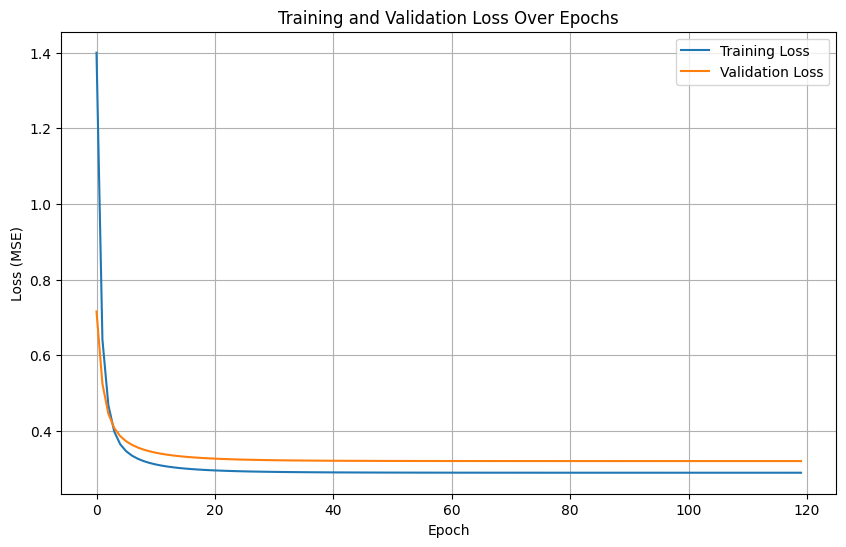

In [37]:
plt.figure(figsize=(10, 6))
plt.plot(range(num_epochs), train_losses, label='Training Loss')
plt.plot(range(num_epochs), val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Training and Validation Loss Over Epochs')
plt.legend()
plt.grid(True)
plt.show()